----

# Análisis exploratorio de datos.

In [1]:
#Importamos las librerías necesarias
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
#Importamos los csv y los definimos como DataFrame
df_company_trips = pd.read_csv('datasets/project_sql_result_01.csv')
df_average_location = pd.read_csv('datasets/project_sql_result_04.csv')

In [4]:
#Obtenemos la información del DF
df_company_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


Visualizamos que no existe datos ausentes y los tipos de datos son correctos según las columnas del DF.

In [5]:
#Obtenemos una primera vista de los datos del DF
df_company_trips.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [6]:
#Obtenemos la información del DF
df_average_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


Visualizamos que no existe datos ausentes y los tipos de datos son correctos según las columnas del DF.

In [73]:
#Obtenemos una primera vista de los datos del DF
df_average_location.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [7]:
#Identificamos los 10 principales barrios en términos de finalización del recorrido
df_average_location.sort_values('average_trips', ascending=False).head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


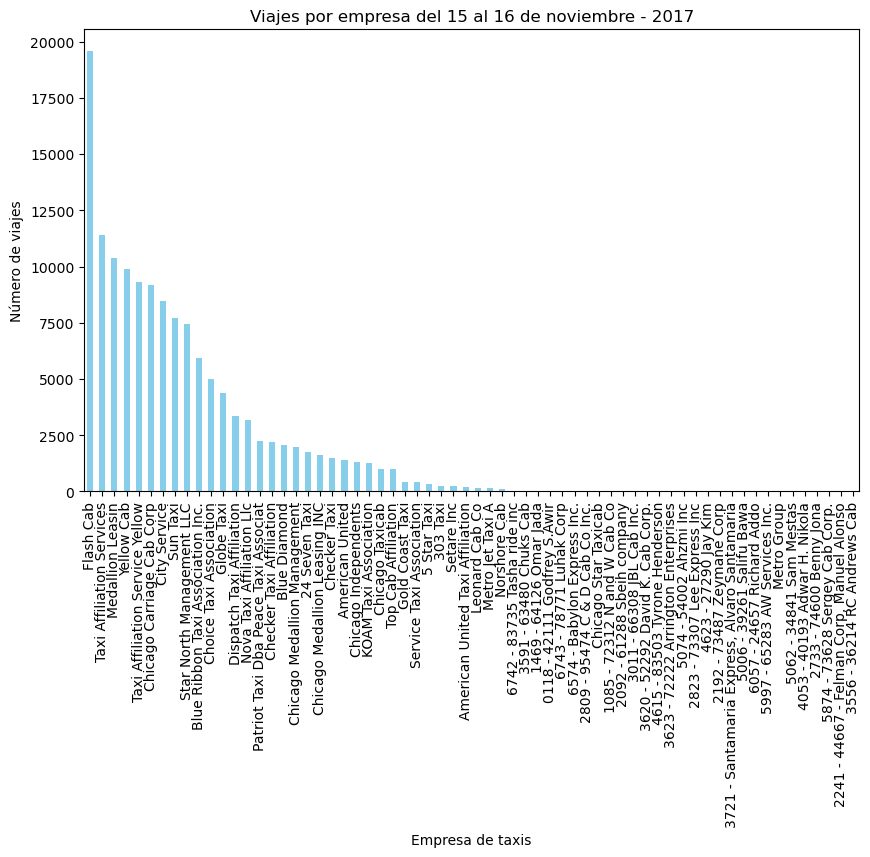

In [8]:
#Empresas de taxis y número de viajes
top_trips = df_company_trips.groupby('company_name')['trips_amount'].sum().sort_values(ascending=False)
top_trips.plot(x='company_name', 
               kind='bar', 
               figsize=(10,6), 
               title='Viajes por empresa del 15 al 16 de noviembre - 2017', 
               xlabel='Empresa de taxis', 
               ylabel='Número de viajes', 
               color='skyblue')
plt.show()

La empresa "Flash Cab" realizó la mayor cantidad de viajes entre el 15 y 16 de noviembre de 2017, seguida por "Taxi Affiliation Services" y "Medallion Leasin". Hay una marcada diferencia entre las empresas líderes y el resto, lo que indica que el mercado está concentrado en pocas compañías principales. Las empresas con menos viajes tienen una participación muy baja en comparación con las líderes.

Esto sugiere que los pasajeros prefieren ciertas compañías, posiblemente por reputación, cobertura o calidad del servicio. Además, la concentración puede influir en la competencia y en las estrategias de las empresas más pequeñas para captar más clientes.

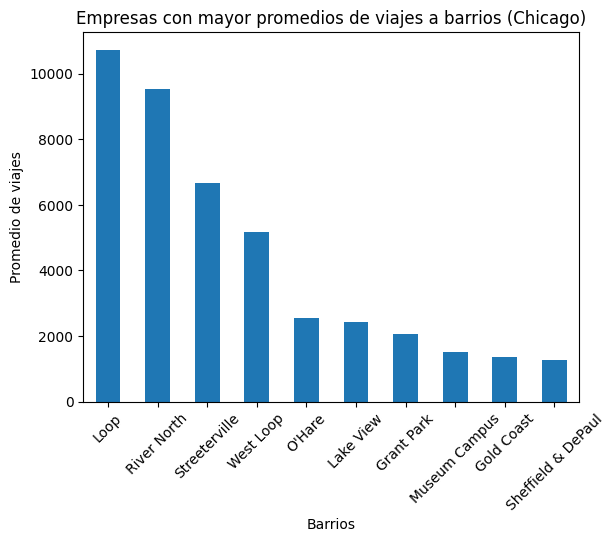

In [76]:
#Los 10 barrios principales por número de finalizaciones
top_10_neighborhoods = df_average_location.groupby('dropoff_location_name')['average_trips'].sum()
top_10_neighborhoods.sort_values(ascending=False).head(10).plot(x='dropoff_location_name', 
                                                                kind='bar', 
                                                                xlabel='Barrios', 
                                                                ylabel='Promedio de viajes', 
                                                                title='Empresas con mayor promedios de viajes a barrios (Chicago)', 
                                                                rot=45)
plt.show()

El barrio "Loop" tiene mayor promedio de viajes finalizados, seguido de los barrios "River North" y "Streeterville" para noviembre del 2017. Esto indica que estas zonas son las más concurridas y demandadas para el servicio de taxi, probablemente por ser áreas comerciales, turísticas o de negocios. Los barrios con menor promedio de viajes reflejan menor actividad de taxis, lo que puede estar relacionado con menor densidad poblacional, menor actividad económica o menor demanda de transporte en esas zonas.

# Prueba de hipótesis.

## Vamos a probar la la hipótesis:
"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Definimos la hipótesis nula(H0) y la alternativa(H1):

* H0 = 'La duración promedio de los viajes desde Loop hasta el Aereopuerto Internacional O'Hare no cambia los sábados lluviosos'.

* H1 = 'La duración promedio de los viajes desde Loop hasta el Aereopuerto Internacional O'Hare si cambia los sábados lluviosos'.

In [77]:
#Importamos librería para realizar prueba de hipótesis
from scipy import stats as st

In [78]:
#Importamos los csv y los definimos como DataFrame
df_trips_loop_aereopuerto = pd.read_csv('/datasets/project_sql_result_07.csv')

In [79]:
#Obtenemos información del DF
df_trips_loop_aereopuerto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [80]:
#Obtenemos las primeras filas del DF
df_trips_loop_aereopuerto.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [81]:
#Obtenemos los viajes para los sábados lluviosos
bad_conditions = df_trips_loop_aereopuerto.query('weather_conditions == "Bad"')['duration_seconds']
bad_conditions.reset_index(drop=True)

0      2969.0
1      1980.0
2      2460.0
3      2760.0
4      2460.0
        ...  
175    2560.0
176    1908.0
177    2400.0
178    2186.0
179    2834.0
Name: duration_seconds, Length: 180, dtype: float64

In [82]:
#Obtenemos los viajes para los sábados no lluviosos
good_conditions = df_trips_loop_aereopuerto.query('weather_conditions == "Good"')['duration_seconds'].head(180)
good_conditions.reset_index(drop=True)

0      2410.0
1      1920.0
2      1543.0
3      2512.0
4      1440.0
        ...  
175       0.0
176    1414.0
177    1981.0
178    1200.0
179    2160.0
Name: duration_seconds, Length: 180, dtype: float64

Se generó dos muestras de igual cantidad de elementos, una para los viajes en sábados lluviosos `bad_conditions` y otra para los viajes en sábados en que no llovió `good_conditions`.
Ahora usaremos Hipótesis sobre la igualdad de las medias de dos poblaciones, dado queremos saber si dos grupos de datos son realmente diferentes en promedio; pero primero usaremos la prueba de Levene para confirmar si las dos muestras tienen varianzas iguales o no, necesario para nuestra prueba de hipótesis.

In [90]:
#Definimos el nivel de significacia como 0.05 (5%)
alpha = 0.05

#Prueba de LEVENE
stat, p = st.levene(bad_conditions, good_conditions)
print(f'Valor de p_levene: {p}')

#Definimos el valor de equal_var que se usará en la prueba de hipótesis
if p > 0.05:
    eql_var = True
else:
    eql_var = False

#Realizamos prueba de hipótesis
statistic, p_value = st.ttest_ind(bad_conditions, good_conditions, equal_var=equal_var)
print('Valor p: ', p_value)

if p_value < alpha:
    print('Rechazamos la hipótesis nula (H0)')
else:
    print('No podemos rechazar la hipótesis nula (H0)')

Valor de p_levene: 0.9983819512672181
Valor p:  1.0383617101347517e-11
Rechazamos la hipótesis nula (H0)


Lo que significa que hay evidencia estadística suficiente para concluir que la duración promedio de los viajes desde Loop hasta el Aereopuerto Internacional O'Hare, si cambia los sábados lluviosos.